In [1]:
import pandas as pd
import numpy as np
import pickle
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, KFold
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    root_mean_squared_error,
    mean_squared_error,
    mean_absolute_error,
    make_scorer,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore")

/Users/ilya.katliarou/Documents/CCF/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("src/data/training/raw/merged_training_data.csv")

In [3]:
df['mix__sd_od_history_to_kyc_ratio'] = df['od__history_length_days'] / df['sd__age_since_first_kyc']

In [4]:
ordinal_features = [
    "cb__worst_score",
    "sd__membership_product"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__worst_score
        ["PERSONAL_FLEX", "PERSONAL_STANDARD", "PERSONAL_SMART"
         , "PERSONAL_YOU", "PERSONAL_METAL", "BUSINESS_STANDARD"
         , "BUSINESS_SMART", "BUSINESS_YOU", "BUSINESS_METAL", np.nan]        # sd__membership_product
    ],
    encoded_missing_value=np.nan
)

df[ordinal_features] = ordinal_encoder.fit_transform(
    df[ordinal_features]
)

In [5]:
reg_feats = ['t__ccf',
'ob__limit_ref',
 'ob__max_to_avg_util_3m_ratio',
 'ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__max_util_3m',
 'ob__avg_util_3m',
 'madrid__avg_monthly_expenses_3m',
 'ob__od_enabled_zero_util_days_6m',
 'ob__partial_repayment_events_6m',
 'mix__sd_od_history_to_kyc_ratio',
 'sd__age_since_last_kyc',
 'ab__std_abs_change_6m',
 'sd__age',
 'ob__util_last2m_to_first2m_1y_ratio',
 'sd__max_daily_logins_12m',
 'ob__std_util_3m',
 'ab__bal_change_freq_3m',
 'ob__od_draw_days_6m',
 'sd__max_daily_logins_6m',
 'sd__age_since_first_kyc',
 'madrid__avg_monthly_salary_3m',
 'ab__max_one_day_drop_6m',
 'cb__worst_score',
 'mv__is_lisbon_v1',
 'ul__is_expat',
 'ab__inflow_spike_count_6m',
 'ob__util_range_3m',
 'ob__avg_util_change_last2m_to_first2m_1y',
 'madrid__avg_monthly_repayment_capacity_3m',
 'sd__membership_product']
clf_feats = ['ob__open_limit_ref',
 'ob__avg_util_ref',
 'ob__limit_ref',
 'madrid__avg_monthly_salary_3m',
 'ul__is_expat',
 'ob__od_enabled_zero_util_days_6m',
 'madrid__avg_monthly_expenses_3m',
 'sd__age',
 'ob__max_to_avg_util_3m_ratio',
 'ob__max_util_change_3m',
 'sd__max_daily_logins_6m',
 'ab__avg_bal_3m',
 'cb__worst_score',
 'mix__sd_od_history_to_kyc_ratio',
 'ab__days_down_6m',
 'ab__inflow_spike_count_6m',
 'sd__max_daily_logins_12m',
 'ab__std_abs_change_6m',
 'ab__std_bal_change_3m',
 'ab__near_zero_days_6m',
 'ab__bal_change_freq_3m',
 'ep__cc_tbil_balance',
 'madrid__avg_monthly_repayment_capacity_3m',
 'ab__max_bal_change_3m',
 'ob__util_last2m_to_first2m_ratio',
 'ab__avg_bal_change_3m',
 'ob__avg_util_3m',
 'ab__max_one_day_drop_6m',
 'mv__is_lisbon_v1',
 'ob__partial_repayment_events_6m']

In [6]:
df_test = df.sample(frac=0.1, random_state=42)

df_train = df.drop(df_test.index)

In [7]:
y_reg = df_train['t__ccf']
y_clf = df_train['t__is_drawn']

X = df_train

In [8]:
X_train, X_val, y_train_reg, y_val_reg = train_test_split(X, y_reg, test_size=0.1, random_state=42)
_, _, y_train_clf, y_val_clf = train_test_split(X, y_clf, test_size=0.1, random_state=42)

In [9]:
X_train_reg = X_train[reg_feats]
X_val_reg = X_val[reg_feats]

X_train_reg = X_train_reg[X_train_reg['t__ccf'] > 0]
y_train_reg = y_train_reg[y_train_reg > 0]

X_train_reg = X_train_reg.drop(columns=['t__ccf'])
X_val_reg = X_val_reg.drop(columns=['t__ccf'])

X_train_clf = X_train[clf_feats]
X_val_clf = X_val[clf_feats]

In [54]:
reg_xgb = XGBRegressor(
    eval_metric='mae',
    random_state=42,
    n_estimators=1500
)

In [55]:
param_dist_logit = {
    'objective': ['reg:squarederror'],

    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 20),
    'gamma': uniform(0.0, 0.3),

    'subsample': uniform(0.6, 0.9),
    'colsample_bytree': uniform(0.6, 1.0),

    'reg_alpha': uniform(0.0, 0.5),
    'reg_lambda': uniform(0.5, 2.0),

    'eta': uniform(0.01, 0.2),

    'max_delta_step': randint(0, 5)
}

In [68]:
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)

random_search_reg = RandomizedSearchCV(
    estimator=reg_xgb,
    param_distributions=param_dist_logit,
    n_iter=1000,
    scoring=mae_scorer,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_reg.fit(X_train_reg, y_train_reg)

print("Best MAE for Regression:", -random_search_reg.best_score_)
print("Best Params for Regression:", random_search_reg.best_params_)
best_reg_model = random_search_reg.best_estimator_

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, gamma=0.21959818254342153, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.22291637642679557, reg_lambda=0.6999498316360058, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, gamma=0.21959818254342153, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.22291637642679557, reg_lambda=0.6999498316360058, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, gamma=0.21959818254342153, max_delta_step=4, max_depth=7, min_child_weight=7, objective=reg:squarederror, reg_alpha=0.22291637642679557, reg_lambda=0.6999498316360058, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.9745401188473625, eta=0.20014286128198325, 

In [69]:
with open("xgb_reg_ccf.pkl", "wb") as f:
    pickle.dump(best_reg_model, f)

In [10]:
with open("xgb_reg_ccf.pkl", "rb") as f:
    best_reg_model = pickle.load(f)

In [11]:
best_reg_model.get_params()

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': np.float64(0.6537819641773779),
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'mae',
 'feature_types': None,
 'feature_weights': None,
 'gamma': np.float64(0.10738835835982939),
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': 4,
 'max_depth': 9,
 'max_leaves': None,
 'min_child_weight': 17,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': np.float64(0.4195498493998058),
 'reg_lambda': np.float64(1.6013209184731285),
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': np.float64(0.7378

In [12]:
y_pred_reg = best_reg_model.predict(X_val_reg)

In [13]:
y_pred_reg = best_reg_model.predict(X_val_reg)
mse = mean_squared_error(y_val_reg, y_pred_reg)
rmse = root_mean_squared_error(y_val_reg, y_pred_reg)
print("MSE:", mse, "RMSE:", rmse)

MSE: 0.2779255786943606 RMSE: 0.5271864743090063


In [74]:
pos = (y_train_clf==1).sum()
neg = (y_train_clf==0).sum()
imbalance_ratio = neg/pos

clf_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_estimators=1500,
    learning_rate=0.01,
)

In [75]:
param_dist_clf = {
    'max_depth': randint(2, 6),
    'min_child_weight': randint(1, 7), 
    'gamma': uniform(0.0, 0.2),
    'subsample': uniform(0.6, 0.9), 
    'colsample_bytree': uniform(0.3, 0.6),
    'reg_alpha': uniform(0.0, 0.3),
    'reg_lambda': uniform(0.0, 0.4),
    'scale_pos_weight': [0.0, 0.5, 1.0, 1.5, 2.0] 
}

In [76]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search_clf = RandomizedSearchCV(
    estimator=clf_xgb,
    param_distributions=param_dist_clf,
    n_iter=1000,
    scoring='roc_auc',
    cv=skf,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search_clf.fit(X_train_clf, y_train_clf)

print("Best AUC for Classification:", random_search_clf.best_score_)
print("Best Params for Classification:", random_search_clf.best_params_)
best_clf_model = random_search_clf.best_estimator_

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; total time=   0.1s
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805; total time=   0.0s
[CV] END colsample_bytree=0.5247240713084175, gamma=0.19014286128198324, max_depth=4, min_child_weight=5, reg_alpha=0.1790550473839461, reg_lambda=0.17833310114143647, scale_pos_weight=1.0, subsample=1.0133240027692805

In [81]:
with open("xgb_clf_ccf.pkl", "wb") as f:
    pickle.dump(best_clf_model, f)

In [14]:
with open("xgb_clf_ccf.pkl", "rb") as f:
    best_clf_model = pickle.load(f)

In [15]:
best_clf_model.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': np.float64(0.7037082800931268),
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': 'logloss',
 'feature_types': None,
 'feature_weights': None,
 'gamma': np.float64(0.14485090549982665),
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.01,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 3,
 'max_leaves': None,
 'min_child_weight': 3,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 1500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': np.float64(0.19002352207263812),
 'reg_lambda': np.float64(0.3222103654304228),
 'sampling_method': None,
 'scale_pos_weight': 0.5,
 'subsample': np.float64(0

In [16]:
y_pred_clf = best_clf_model.predict_proba(X_val_clf)[:,1]
y_pred_clf_binary = (y_pred_clf >= 0.5).astype(int)

In [17]:
roc_auc = roc_auc_score(y_val_clf, y_pred_clf)
precision = precision_score(y_val_clf, y_pred_clf_binary)
recall = recall_score(y_val_clf, y_pred_clf_binary)
f1 = f1_score(y_val_clf, y_pred_clf_binary)
accuracy = accuracy_score(y_val_clf, y_pred_clf_binary)

print("ROC AUC:", roc_auc)
print(f"Accuracy: {accuracy:.4f}  Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")

ROC AUC: 0.7021984024374355
Accuracy: 0.6771  Precision: 0.7849  Recall: 0.7352  F1: 0.7593


In [ ]:
from sklearn.metrics import precision_recall_curve, f1_score

y_pred_proba = best_clf_model.predict_proba(X_val_clf)[:, 1]
y_true_class_val = y_val_clf

precision, recall, thresholds = precision_recall_curve(y_true_class_val, y_pred_proba)

fscores = 2 * (precision * recall) / (precision + recall)
ix = np.argmax(fscores)
best_threshold = thresholds[ix]

print('Best Threshold=%f, F1-Score=%.3f' % (best_threshold, fscores[ix]))

In [ ]:
best_clf_model.fit(X_train_clf, y_train_clf)

explainer = shap.TreeExplainer(best_clf_model)
shap_values = explainer.shap_values(X_train_clf)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.Series(mean_abs_shap, index=X_train_clf.columns)
    .sort_values(ascending=False)
)

top_shap_clf = shap_importance.head(35).index.tolist()

In [ ]:
top_shap_clf

In [ ]:
best_reg_model.fit(X_train_reg, y_train_reg)

explainer = shap.TreeExplainer(best_reg_model)
shap_values = explainer.shap_values(X_train_reg)

top_shap_reg = (
    pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_reg.columns)
    .sort_values(ascending=False)
    .head(35)
    .index.tolist()
)

In [ ]:
top_shap_reg

In [ ]:
from sklearn.metrics import roc_auc_score

results = []

for k in [5, 10, 15, 20, 25, 30, 40, 60, 100]:
    feats = top_shap_clf[:k]

    best_clf_model.fit(X_train_clf[feats], y_train_clf)

    preds = best_clf_model.predict_proba(X_val[feats])[:, 1]
    auc = roc_auc_score(y_val_clf, preds)

    results.append((k, auc))

perf_df = pd.DataFrame(results, columns=["n_features", "auc"])

In [ ]:
perf_df

# Test Set and hurdle model

In [19]:
y_test_reg = df_test['t__ccf']
y_test_clf = df_test['t__is_drawn']

In [20]:
X_test_reg = df_test[reg_feats]
X_test_reg = X_test_reg.drop(columns=['t__ccf'])
X_test_clf = df_test[clf_feats]

In [ ]:
threshold = 0.215518

def predict_ccf(X_clf, X_reg, best_clf_model, best_reg_model, threshold, upper_clipping_limit=2.0, bottom_clipping_limit=0.0):
    """
    Applies the Hurdle Model logic to predict CCF for new data.
    """

    clf_probabilities = best_clf_model.predict_proba(X_clf)[:, 1]
    predicted_ccf = np.zeros(X_clf.shape[0])
    non_zero_indices = clf_probabilities >= threshold
    
    if np.any(non_zero_indices):

        X_reg_input = X_reg[non_zero_indices]
        reg_predictions = best_reg_model.predict(X_reg_input)
        
        final_values = np.clip(reg_predictions, a_min=bottom_clipping_limit, a_max=upper_clipping_limit)
        
        predicted_ccf[non_zero_indices] = final_values
        
    return predicted_ccf

In [22]:
final_predictions = predict_ccf(X_clf=X_test_clf,
                                X_reg=X_test_reg,
                                           best_clf_model=best_clf_model,
                                           best_reg_model=best_reg_model,
                                           threshold=threshold,
                                           bottom_clipping_limit=0.0,
                                           upper_clipping_limit=1.0)

NameError: name 'predict_ccf' is not defined

In [21]:
y_pred_test_clf = best_clf_model.predict_proba(X_test_clf)[:,1]
y_pred_test_reg = best_reg_model.predict(X_test_reg)

In [24]:
y_pred = y_pred_test_clf*np.clip(a=y_pred_test_reg, a_min=0.0, a_max=1.0)
mse = mean_squared_error(y_test_reg, y_pred)
print("MSE:", mse)

MSE: 0.19229341240073256


In [29]:
y_test_reg

1087     0.59138
10052    1.00000
8722     1.00000
8747     0.00000
13614    0.00000
          ...   
13145    0.32271
1491     0.00000
7356     0.05212
13848    0.89048
13254    1.00000
Name: t__ccf, Length: 1521, dtype: float64

In [92]:
from sklearn.metrics import mean_squared_error, r2_score
rmse = root_mean_squared_error(y_test_reg,y_pred)
print(f"RMSE: {rmse}")

RMSE: 0.4385127277522655


Calibration by Decile:
   decile  predicted    actual
0       0   0.177874  0.222468
1       1   0.308077  0.396338
2       2   0.377691  0.463508
3       3   0.424700  0.551260
4       4   0.467400  0.624265
5       5   0.508071  0.631264
6       6   0.550785  0.682843
7       7   0.595019  0.752511
8       8   0.653098  0.717907
9       9   0.801133  0.857052

Metrics by Decile:
   decile       mse      rmse  count
0       0  0.142105  0.376969  153.0
1       1  0.220982  0.470087  152.0
2       2  0.223081  0.472314  152.0
3       3  0.230970  0.480593  152.0
4       4  0.222621  0.471827  152.0
5       5  0.206425  0.454340  152.0
6       6  0.204338  0.452038  152.0
7       7  0.188211  0.433833  152.0
8       8  0.177992  0.421891  152.0
9       9  0.106539  0.326404  152.0


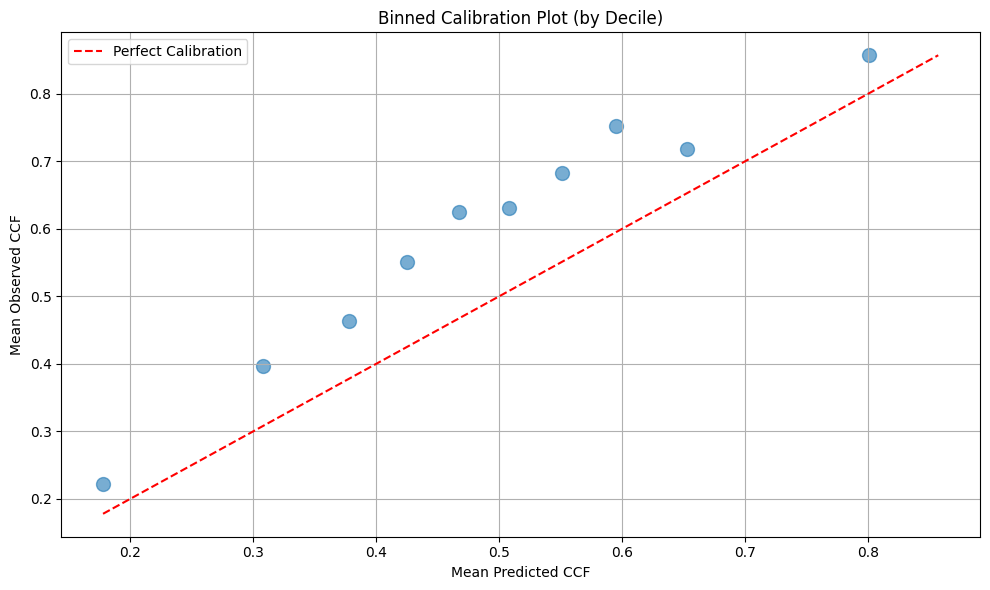

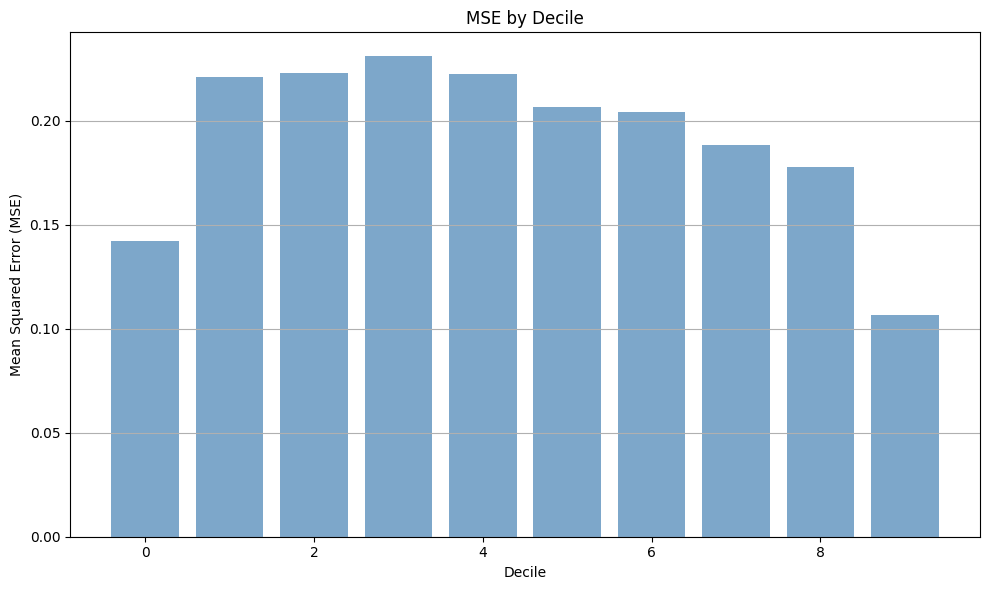

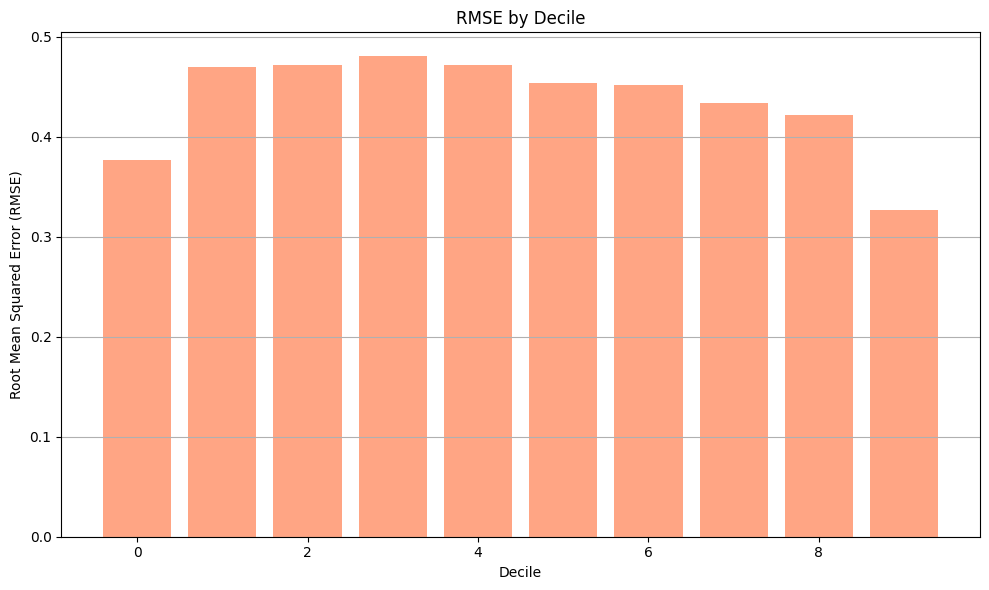

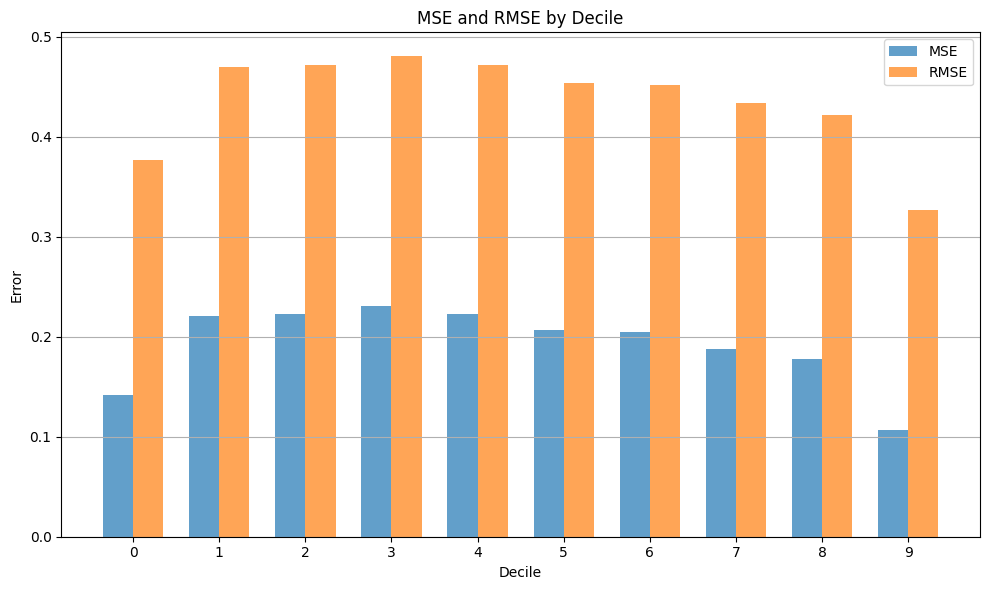

In [95]:
y_test = y_test_reg
y_pred = y_pred = y_pred_test_clf*np.clip(a=y_pred_test_reg, a_min=0.0, a_max=1.0)

df_eval = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred
})

df_eval['decile'] = pd.qcut(df_eval['predicted'], q=10, labels=False, duplicates='drop')

calibration = df_eval.groupby('decile').agg({
    'predicted': 'mean',
    'actual': 'mean'
}).reset_index()

metrics_by_decile = df_eval.groupby('decile').apply(
    lambda x: pd.Series({
        'mse': mean_squared_error(x['actual'], x['predicted']),
        'rmse': np.sqrt(mean_squared_error(x['actual'], x['predicted'])),
        'count': len(x)
    })
).reset_index()

print("Calibration by Decile:")
print(calibration)
print("\nMetrics by Decile:")
print(metrics_by_decile)

# Plot 1: Binned Calibration Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(calibration['predicted'], calibration['actual'], s=100, alpha=0.6)
# Plot perfect calibration line
min_val = min(calibration['predicted'].min(), calibration['actual'].min())
max_val = max(calibration['predicted'].max(), calibration['actual'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Calibration')
ax.set_xlabel('Mean Predicted CCF')
ax.set_ylabel('Mean Observed CCF')
ax.set_title('Binned Calibration Plot (by Decile)')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(metrics_by_decile['decile'], metrics_by_decile['mse'], alpha=0.7, color='steelblue')
ax.set_xlabel('Decile')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('MSE by Decile')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(metrics_by_decile['decile'], metrics_by_decile['rmse'], alpha=0.7, color='coral')
ax.set_xlabel('Decile')
ax.set_ylabel('Root Mean Squared Error (RMSE)')
ax.set_title('RMSE by Decile')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics_by_decile))
width = 0.35
ax.bar(x - width/2, metrics_by_decile['mse'], width, label='MSE', alpha=0.7)
ax.bar(x + width/2, metrics_by_decile['rmse'], width, label='RMSE', alpha=0.7)
ax.set_xlabel('Decile')
ax.set_ylabel('Error')
ax.set_title('MSE and RMSE by Decile')
ax.set_xticks(x)
ax.set_xticklabels(metrics_by_decile['decile'])
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

 96%|=================== | 1461/1521 [00:15<00:00]       

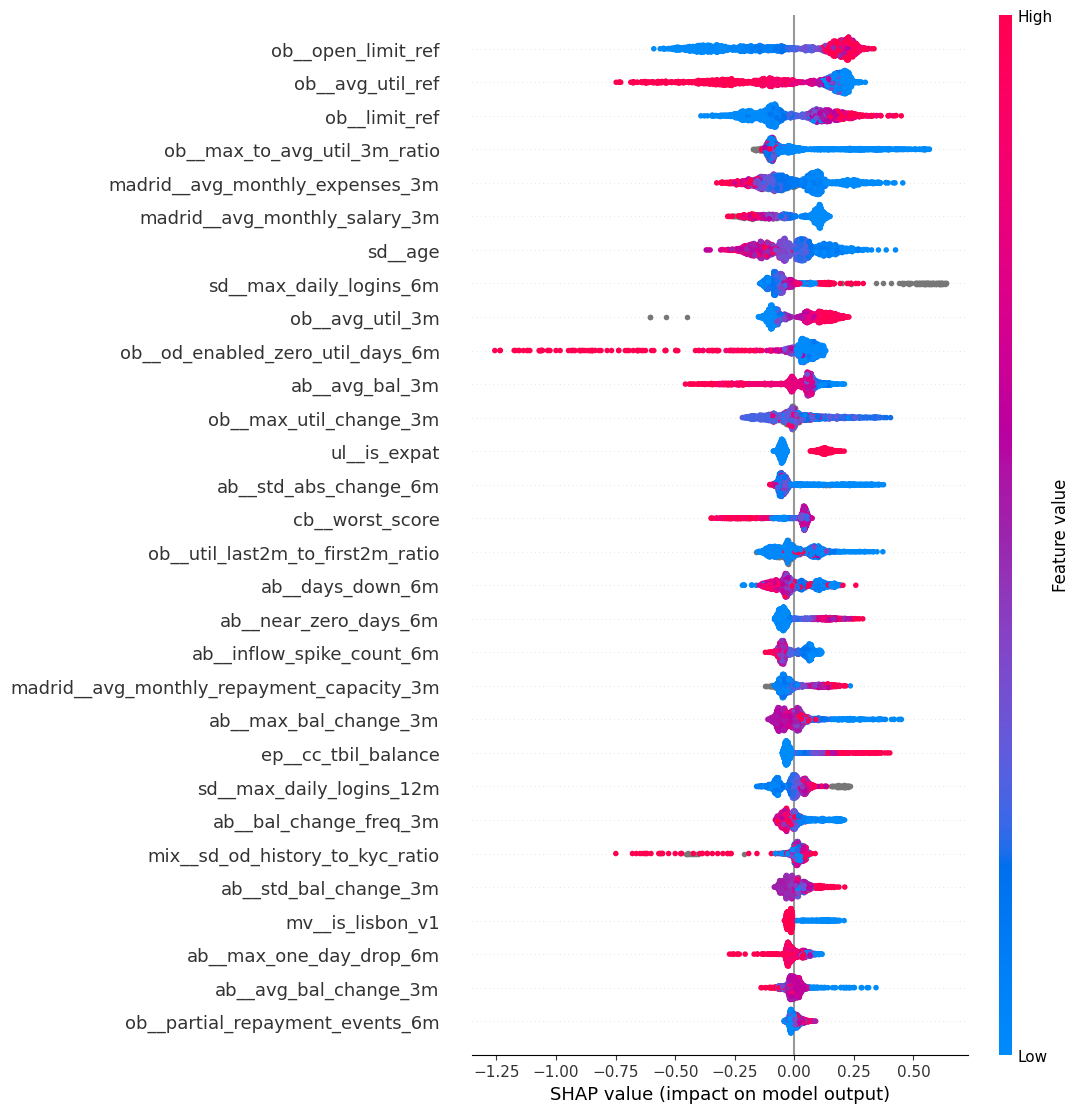

In [96]:
explainer = shap.Explainer(best_clf_model, X_test_clf)
shap_values = explainer(X_test_clf)

shap.plots.beeswarm(shap_values, max_display=30)

 99%|===================| 1503/1521 [00:42<00:00]        

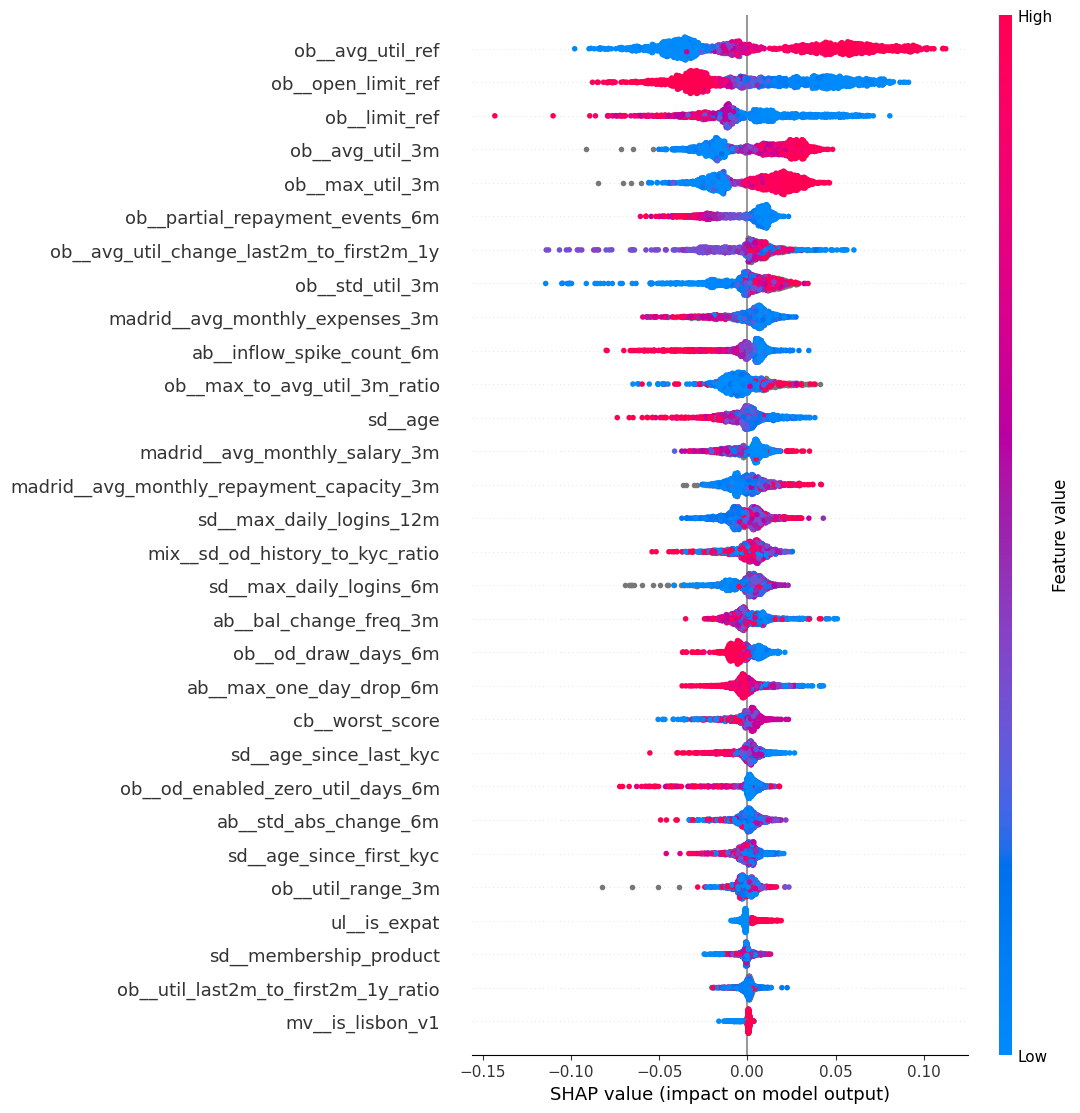

In [97]:
explainer = shap.Explainer(best_reg_model, X_test_reg)
shap_values = explainer(X_test_reg)

shap.plots.beeswarm(shap_values, max_display=30)